In [1]:
# %% SECTION 1: Packages import
import os
import numpy as np

# Import other packages as necessary
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from scipy.optimize import least_squares


In [2]:
# %% SECTION 2: Helper functions
# Define functions if needed
# Bounds: [e_r, g_bar, tau_m, tau_h]
lower = np.array([-150, 0,    0.01, 0.01])
upper = np.array([ 150, 1,    1e3,  1e4 ])
rng = np.random.default_rng(0)   # fixed seed -> reproducible
n_starts = 20

def gate_model(tau, x_0,x_inf,dt):
    y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))
    return y

#probably needs to be fixed, we need to make the gates opening dependent on voltage as well somehow
def get_current(e_r, g_bar, tau_m, tau_h, m_inf, h_inf, v, t, v_steps):
    m = np.zeros(len(v))
    h = np.zeros(len(v))

    m[0] = 0
    h[0] = 1

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        v_prev = v[i-1]

        m_inf_step = np.interp(v[i], v_steps, m_inf)
        h_inf_step = np.interp(v[i], v_steps, h_inf)
        m[i] = gate_model(tau_m, m[i-1], m_inf_step, dt)
        h[i] = gate_model(tau_h, h[i-1], h_inf_step, dt)

    return g_bar * (v - e_r) * m * h

def compute_error(params, t, v, test_i, v_steps):
    e_r, g_bar, tau_m, tau_h = params[:4]
    m_inf = params[4:4+len(v_steps)]
    h_inf = params[4+len(v_steps):4+2*len(v_steps)]
    return get_current(e_r, g_bar, tau_m, tau_h, m_inf, h_inf, v, t, v_steps) - test_i

def random_start():
    e_r   = rng.uniform(-100, 50)
    g_bar = 10 ** rng.uniform(-5, -1)
    tau_m = 10 ** rng.uniform(-1, 2)
    tau_h = 10 ** rng.uniform(0, 3)
    return [e_r, g_bar, tau_m, tau_h]

start 0: cost = 0.1185, success = True, params = [-4.72800241e+01  9.86884797e+00  3.23360977e+00  6.74865682e-03
  1.01161064e-02  8.30459164e-02  1.08111083e-01  1.21351522e-01
  8.62680591e-02  3.45155593e-02  1.58760244e-03  2.82247829e-03
 -2.27101573e-03 -1.11391745e-04  1.67118883e-04  7.44660045e-04]
start 1: cost = 0.1185, success = True, params = [-4.72800241e+01  9.86884797e+00  3.23360977e+00  6.74865682e-03
  1.01161064e-02  8.30459164e-02  1.08111083e-01  1.21351522e-01
  8.62680591e-02  3.45155593e-02  1.58760244e-03  2.82247829e-03
 -2.27101573e-03 -1.11391745e-04  1.67118883e-04  7.44660045e-04]
start 2: cost = 0.1185, success = True, params = [-4.72800241e+01  9.86884797e+00  3.23360977e+00  6.74865682e-03
  1.01161064e-02  8.30459164e-02  1.08111083e-01  1.21351522e-01
  8.62680591e-02  3.45155593e-02  1.58760244e-03  2.82247829e-03
 -2.27101573e-03 -1.11391745e-04  1.67118883e-04  7.44660045e-04]
start 3: cost = 0.1185, success = True, params = [-4.72800241e+01  9.8

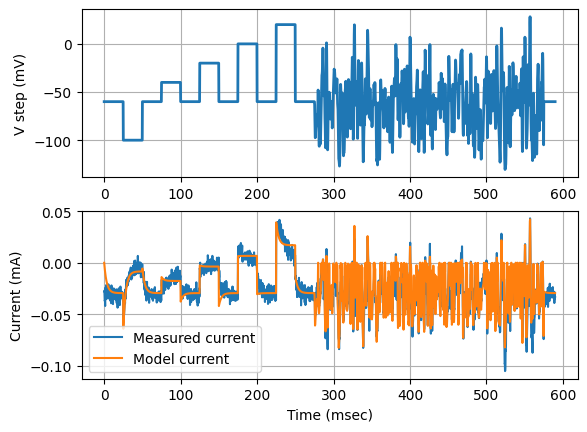

In [4]:
# %% SECTION 3: Main function
def run_vclamp_model(folder: str, data: str = "CookLab1UnknownChannel.txt"):
    """
    Compute current from voltage-clamp input.

    Parameters
    ----------
    folder :
        Directory with input file for voltage-clamp model.
    data :
        Name of input file.
    # Please list any parameters added to the function.

    Returns
    -------
    np.ndarray
        Output current computed by the voltage-clamp model.
    """
    # %% SECTION 3-a: Load provided input data.
    # NO MODIFICATIONS: This section should be kept as is.
    data = np.loadtxt(os.path.join(folder, "data/CookLab1UnknownChannel.txt"))
    t = data[:, 0]
    v = data[:, 1]

    # i has the same shape as array v, add code in the next section to fill it
    
    i = np.empty_like(v)

    # %% SECTION 3-b: Compute i [to be filled by students]
    test_i = data[:,2]

    v_steps = [-100, -60, -40, -20, 0, 20]
    initial_m_inf = [0.01, 0.05, 0.2, 0.5, 0.8, 0.95]
    initial_h_inf = [0.99, 0.95, 0.8, 0.5, 0.2, 0.05]
    
    fits = []
    for i in range(n_starts):
        x0 = random_start()
        fit = least_squares(compute_error, args = (t, v, test_i, v_steps), x0 = [-60, 10, 1, 1, *initial_m_inf, *initial_h_inf])
        fits.append(fit)
        print(f"start {i}: cost = {fit.cost:.4f}, success = {fit.success}, params = {fit.x}")
    best = min(fits, key=lambda f: f.cost)
    print("Best parameters:", best.x)
    fit = best
    i = get_current(fit.x[0], fit.x[1],fit.x[2], fit.x[3], fit.x[4:4+len(v_steps)], fit.x[4+len(v_steps):4+2*len(v_steps)], v, t, v_steps)

    ss_res = np.sum((test_i - i) ** 2)
    ss_tot = np.sum((test_i - np.mean(test_i)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print("R-squared:", r_squared)

    print("Fitted parameters:", fit.x)
    print("Fit succeeded:", fit.success)    
    
    
    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(t, v, linewidth=2)
    plt.axis("tight")
    plt.ylabel("V step (mV)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(t, test_i, label="Measured current")
    plt.plot(t, i, label="Model current")
    plt.xlabel("Time (msec)")
    plt.ylabel("Current (mA)")
    plt.legend()

    # %% SECTION 3-c: Assert validity of output and return it.
    # NO MODIFICATIONS: This section should be kept as is.
    assert len(i.shape) == 1, "Currrent array should be 1-dimensional"
    return i

fitted = run_vclamp_model(os.getcwd())


/var/folders/fz/hgcbgwt92wjcykm_7xssbsh40000gn/T/ipykernel_39949/3511319195.py:5: RuntimeWarning: overflow encountered in double_scalars
  y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))


Fitted parameters: [-7.27241041e+00  5.24971797e-04  5.99143262e-02  6.98429334e+07]
Fit succeeded: True


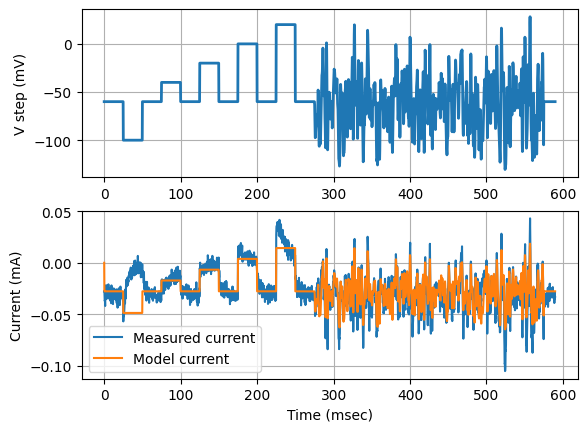

In [7]:
# %% SECTION 4: Function calls
if __name__ == "__main__":
    # Replace this with the path to the folder where provided input .txt file is!
    folder = ""

    # Run function on the voltage-clamp data
    i = run_vclamp_model(folder)